In [ ]:
# Customer Retention & Revenue Optimization Analysis

## Business Objective
Analyze transaction data to understand revenue drivers, customer retention patterns, churn rate, and identify growth opportunities.

In [ ]:
## Data Cleaning
Prepare dataset by handling missing values, creating revenue column, and formatting dates for analysis.

In [3]:
import pandas as pd
df = pd.read_csv(r"C:\Users\shrao\Downloads\online_retail.csv", encoding="ISO-8859-1")
df.head()

,ï»¿InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   ï»¿InvoiceNo  541909 non-null  object 
 1   StockCode     541909 non-null  object 
 2   Description   540455 non-null  object 
 3   Quantity      541909 non-null  int64  
 4   InvoiceDate   541909 non-null  object 
 5   UnitPrice     541909 non-null  float64
 6   CustomerID    406829 non-null  float64
 7   Country       541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [7]:
df = df.dropna(subset=["CustomerID"])

In [9]:
df["CustomerID"] = df["CustomerID"].astype(int)

In [11]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

In [13]:
df["Revenue"] = df["Quantity"] * df["UnitPrice"]

In [ ]:
## Revenue Metrics
Calculate core business KPIs including Total Revenue, Orders, Customers, and Average Order Value.

In [15]:
total_revenue = df["Revenue"].sum()
total_revenue

8300065.814000001

In [17]:
total_customers = df["CustomerID"].nunique()
total_customers

4372

In [27]:
df.columns = df.columns.str.strip()
df.columns = df.columns.str.replace('ï»¿', '', regex=False)

print(df.columns.tolist())

['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']


In [29]:
total_orders = df["InvoiceNo"].nunique()
total_orders

25900

In [31]:
df["Quantity"].describe()

count    541909.000000
mean          9.552250
std         218.081158
min      -80995.000000
25%           1.000000
50%           3.000000
75%          10.000000
max       80995.000000
Name: Quantity, dtype: float64

In [33]:
df[df["Quantity"] < 0].head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,12/1/2010 9:41,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,12/1/2010 9:49,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,12/1/2010 10:24,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,12/1/2010 10:24,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,12/1/2010 10:24,0.29,17548.0,United Kingdom


In [35]:
df_sales = df[df["Quantity"] > 0].copy()
df_sales["Revenue"] = df_sales["Quantity"] * df_sales["UnitPrice"]

In [37]:
df_returns = df[df["Quantity"] < 0].copy()
df_returns["Revenue"] = df_returns["Quantity"] * df_returns["UnitPrice"]

In [39]:
gross_revenue = df_sales["Revenue"].sum()
gross_revenue

10644560.424

In [41]:
returns_value = df_returns["Revenue"].sum()
returns_value

-896812.49

In [43]:
net_revenue = gross_revenue + returns_value
net_revenue


9747747.934

In [45]:
customer_df = df_sales.groupby("CustomerID").agg({
    "InvoiceNo": "nunique",
    "Revenue": "sum",
    "InvoiceDate": ["min", "max"]
})

In [47]:
customer_df.columns = ["Total_Orders", "Total_Revenue", "First_Purchase", "Last_Purchase"]
customer_df = customer_df.reset_index()

customer_df.head()

,CustomerID,Total_Orders,Total_Revenue,First_Purchase,Last_Purchase
0,12346.0,1,77183.60,1/18/2011 10:01,1/18/2011 10:01
1,12347.0,7,4310.00,1/26/2011 14:30,8/2/2011 8:48
2,12348.0,4,1797.24,1/25/2011 10:42,9/25/2011 13:13
3,12349.0,1,1757.55,11/21/2011 9:51,11/21/2011 9:51
4,12350.0,1,334.40,2/2/2011 16:01,2/2/2011 16:01


In [49]:
analysis_date = df_sales["InvoiceDate"].max()
analysis_date

'9/9/2011 9:52'

In [53]:
df_sales["InvoiceDate"] = pd.to_datetime(df_sales["InvoiceDate"])

In [55]:
customer_df = df_sales.groupby("CustomerID").agg({
    "InvoiceNo": "nunique",
    "Revenue": "sum",
    "InvoiceDate": ["min", "max"]
})

In [57]:
customer_df.columns = ["Total_Orders", "Total_Revenue", "First_Purchase", "Last_Purchase"]
customer_df = customer_df.reset_index()

In [59]:
customer_df.dtypes

CustomerID               float64
Total_Orders               int64
Total_Revenue            float64
First_Purchase    datetime64[ns]
Last_Purchase     datetime64[ns]
dtype: object

In [ ]:
## RFM Segmentation
Classify customers based on Recency, Frequency, and Monetary value to identify high-value and at-risk groups.

In [61]:
analysis_date = df_sales["InvoiceDate"].max()

customer_df["Recency"] = (analysis_date - customer_df["Last_Purchase"]).dt.days

In [65]:
duplicates="drop"

In [69]:
customer_df["F_score"] = pd.qcut(
    customer_df["Total_Orders"],
    5,
    duplicates="drop"
)

customer_df["M_score"] = pd.qcut(
    customer_df["Total_Revenue"],
    5,
    duplicates="drop"
)

customer_df["R_score"] = pd.qcut(
    customer_df["Recency"],
    5,
    duplicates="drop"
)

In [71]:
customer_df["F_score"] = customer_df["F_score"].cat.codes + 1
customer_df["M_score"] = customer_df["M_score"].cat.codes + 1
customer_df["R_score"] = customer_df["R_score"].cat.codes + 1

In [73]:
customer_df["RFM_Score"] = (
    customer_df["R_score"].astype(str) +
    customer_df["F_score"].astype(str) +
    customer_df["M_score"].astype(str)
)

In [75]:
def segment_customer(row):
    if row["R_score"] >= 4 and row["F_score"] >= 4:
        return "Champions"
    elif row["F_score"] >= 4:
        return "Loyal Customers"
    elif row["R_score"] <= 2:
        return "At Risk"
    elif row["F_score"] == 1:
        return "One-Time Buyers"
    else:
        return "Regular"

customer_df["Segment"] = customer_df.apply(segment_customer, axis=1)

In [77]:
customer_df["Segment"].value_counts()

Segment
One-Time Buyers    1801
At Risk            1195
Loyal Customers     665
Regular             643
Champions            35
Name: count, dtype: int64

In [79]:
customer_df["Segment"].value_counts(normalize=True) * 100

Segment
One-Time Buyers    41.507260
At Risk            27.540908
Loyal Customers    15.326112
Regular            14.819083
Champions           0.806637
Name: proportion, dtype: float64

In [81]:
segment_revenue = customer_df.groupby("Segment")["Total_Revenue"].sum().sort_values(ascending=False)
segment_revenue

Segment
Loyal Customers    5371384.960
At Risk            1523437.651
Regular             974654.571
One-Time Buyers     922123.972
Champions           119806.750
Name: Total_Revenue, dtype: float64

In [83]:
segment_revenue_percentage = (
    segment_revenue / segment_revenue.sum()
) * 100

segment_revenue_percentage

Segment
Loyal Customers    60.275380
At Risk            17.095364
Regular            10.937156
One-Time Buyers    10.347680
Champions           1.344420
Name: Total_Revenue, dtype: float64

In [85]:
customer_sorted = customer_df.sort_values(by="Total_Revenue", ascending=False)

In [87]:
customer_sorted["Cumulative_Revenue"] = customer_sorted["Total_Revenue"].cumsum()

In [89]:
customer_sorted["Cumulative_Percentage"] = (
    customer_sorted["Cumulative_Revenue"] /
    customer_sorted["Total_Revenue"].sum()
) * 100

In [91]:
top_80 = customer_sorted[customer_sorted["Cumulative_Percentage"] <= 80]
len(top_80)

1132

In [93]:
(len(top_80) / len(customer_df)) * 100

26.088960589997694

In [95]:
top_80_segments = top_80["Segment"].value_counts(normalize=True) * 100
top_80_segments

Segment
Loyal Customers    53.180212
At Risk            21.819788
Regular            16.961131
One-Time Buyers     5.477032
Champions           2.561837
Name: proportion, dtype: float64

In [ ]:
## Cohort Analysis
Analyze retention trends by grouping customers by first purchase month and tracking repeat behavior over time.

In [97]:
df_sales["CohortMonth"] = df_sales.groupby("CustomerID")["InvoiceDate"].transform("min").dt.to_period("M")

In [99]:
df_sales["PurchaseMonth"] = df_sales["InvoiceDate"].dt.to_period("M")

In [101]:
df_sales["CohortIndex"] = (
    (df_sales["PurchaseMonth"].dt.year - df_sales["CohortMonth"].dt.year) * 12 +
    (df_sales["PurchaseMonth"].dt.month - df_sales["CohortMonth"].dt.month)
)

In [103]:
cohort_data = df_sales.groupby(["CohortMonth", "CohortIndex"])["CustomerID"].nunique().reset_index()

In [105]:
cohort_pivot = cohort_data.pivot(
    index="CohortMonth",
    columns="CohortIndex",
    values="CustomerID"
)

In [107]:
cohort_size = cohort_pivot[0]

retention_matrix = cohort_pivot.divide(cohort_size, axis=0)

retention_matrix

CohortIndex,0,1,2,3,4,5,6,7,8,9,10,11,12
CohortMonth,,,,,,,,,,,,,
2010-12,1.0,0.366102,0.323164,0.384181,0.362712,0.397740,0.362712,0.349153,0.353672,0.395480,0.374011,0.502825,0.265537
2011-01,1.0,0.220624,0.266187,0.230216,0.321343,0.287770,0.247002,0.242206,0.299760,0.326139,0.364508,0.117506,NaN
2011-02,1.0,0.186842,0.186842,0.284211,0.271053,0.247368,0.252632,0.278947,0.247368,0.305263,0.068421,NaN,NaN
2011-03,1.0,0.150442,0.252212,0.199115,0.223451,0.168142,0.267699,0.230088,0.278761,0.086283,NaN,NaN,NaN
2011-04,1.0,0.213333,0.203333,0.210000,0.196667,0.226667,0.216667,0.260000,0.073333,NaN,NaN,NaN,NaN
2011-05,1.0,0.190141,0.172535,0.172535,0.207746,0.232394,0.264085,0.095070,NaN,NaN,NaN,NaN,NaN
2011-06,1.0,0.173554,0.157025,0.264463,0.231405,0.334711,0.095041,NaN,NaN,NaN,NaN,NaN,NaN
2011-07,1.0,0.180851,0.207447,0.223404,0.271277,0.111702,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-08,1.0,0.207101,0.248521,0.242604,0.124260,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [109]:
retention_matrix * 100

CohortIndex,0,1,2,3,4,5,6,7,8,9,10,11,12
CohortMonth,,,,,,,,,,,,,
2010-12,100.0,36.610169,32.316384,38.418079,36.271186,39.774011,36.271186,34.915254,35.367232,39.548023,37.401130,50.282486,26.553672
2011-01,100.0,22.062350,26.618705,23.021583,32.134293,28.776978,24.700240,24.220624,29.976019,32.613909,36.450839,11.750600,NaN
2011-02,100.0,18.684211,18.684211,28.421053,27.105263,24.736842,25.263158,27.894737,24.736842,30.526316,6.842105,NaN,NaN
2011-03,100.0,15.044248,25.221239,19.911504,22.345133,16.814159,26.769912,23.008850,27.876106,8.628319,NaN,NaN,NaN
2011-04,100.0,21.333333,20.333333,21.000000,19.666667,22.666667,21.666667,26.000000,7.333333,NaN,NaN,NaN,NaN
2011-05,100.0,19.014085,17.253521,17.253521,20.774648,23.239437,26.408451,9.507042,NaN,NaN,NaN,NaN,NaN
2011-06,100.0,17.355372,15.702479,26.446281,23.140496,33.471074,9.504132,NaN,NaN,NaN,NaN,NaN,NaN
2011-07,100.0,18.085106,20.744681,22.340426,27.127660,11.170213,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-08,100.0,20.710059,24.852071,24.260355,12.426036,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [111]:
month_1_retention = retention_matrix[1].mean()
month_1_retention

0.20620313494868223

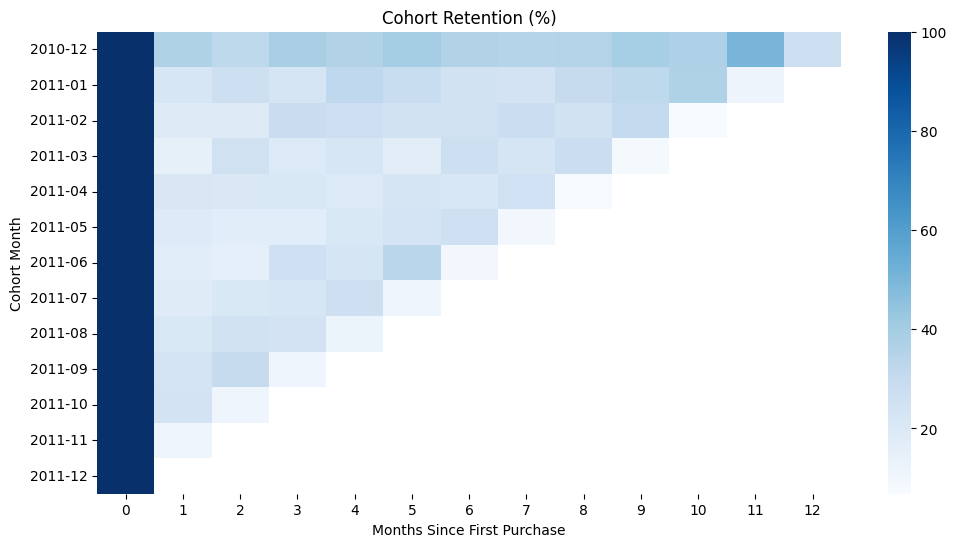

In [113]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.heatmap(retention_matrix * 100, 
            annot=False, 
            fmt=".0f", 
            cmap="Blues")

plt.title("Cohort Retention (%)")
plt.ylabel("Cohort Month")
plt.xlabel("Months Since First Purchase")
plt.show()

In [117]:
avg_retention_by_month = retention_matrix.mean()

In [119]:
avg_retention_by_month * 100

CohortIndex
0     100.000000
1      20.620313
2      22.116316
3      23.244404
4      24.554598
5      25.081173
6      24.369106
7      24.257751
8      25.057906
9      27.829141
10     26.898025
11     31.016543
12     26.553672
dtype: float64

In [121]:
analysis_date = df_sales["InvoiceDate"].max()
analysis_date

Timestamp('2011-12-09 12:50:00')

In [ ]:
## Churn Analysis
Identify customers inactive for more than 90 days and calculate churn rate.

In [123]:
customer_df["Days_Since_Last_Purchase"] = (
    analysis_date - customer_df["Last_Purchase"]
).dt.days

In [125]:
customer_df["Churned"] = customer_df["Days_Since_Last_Purchase"] > 90

In [127]:
churn_rate = customer_df["Churned"].mean() * 100
churn_rate

33.30260428670201

In [129]:
total_revenue = df_sales["Revenue"].sum()
total_orders = df_sales["InvoiceNo"].nunique()

AOV = total_revenue / total_orders
AOV

513.5353350057893

In [131]:
total_customers = customer_df["CustomerID"].nunique()

purchase_frequency = total_orders / total_customers
purchase_frequency

4.7771375893062915

In [ ]:
## Customer Lifetime Value (CLV) Estimation
Estimate customer lifetime value using AOV, purchase frequency, and average lifespan.

In [133]:
avg_lifespan = avg_retention_by_month.sum()
avg_lifespan

4.015989489600244

In [135]:
CLV = AOV * purchase_frequency * avg_lifespan
CLV

9852.141687992329

In [137]:
current_revenue = df_sales["Revenue"].sum()
current_revenue

10644560.424

In [ ]:
## Revenue Growth Simulation
Simulate revenue impact under different strategic scenarios such as increasing AOV, improving retention, and reactivating churned customers.

In [139]:
scenario_A = current_revenue * 1.10
scenario_A

11709016.466400001

In [141]:
scenario_B = current_revenue * 1.05
scenario_B

11176788.445200002

In [143]:
churned_customers = customer_df[customer_df["Churned"] == True]

reactivated_revenue = churned_customers["Total_Revenue"].mean() * len(churned_customers) * 0.10

scenario_C = current_revenue + reactivated_revenue
scenario_C

10747896.8321

In [145]:
customer_df.to_csv("customer_summary.csv", index=False)
retention_matrix.to_csv("cohort_retention.csv")

In [ ]:
## Key Business Insights

- 26% of customers contribute to 80% of revenue
- Month 1 retention is approximately 20%
- Churn rate is 33%
- Loyal customers generate the majority of revenue
- Increasing AOV provides the highest short-term revenue uplift

In [149]:
monthly_revenue = df_sales.groupby(df_sales["InvoiceDate"].dt.to_period("M"))["Revenue"].sum()
monthly_revenue = monthly_revenue.reset_index()
monthly_revenue.to_csv("monthly_revenue.csv", index=False)

In [151]:
customer_df.to_csv("customer_summary.csv", index=False)
retention_matrix.to_csv("cohort_retention.csv")
monthly_revenue.to_csv("monthly_revenue.csv")